<a href="https://colab.research.google.com/github/ciptomx/Clustering-cici/blob/main/final_code_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- PROSES LOADING DATA ---
Ditemukan file Excel (XLSX). Membaca data...

[INFO] 5 Baris Teratas Dataset:


,waktu,windspeed,winddir,temp,rh,pressure,rain,solrad,netrad,watertemp,waterlevel,ta_min,ta_max,pancilevel,pancitemp
0,2021-01-01,1.220112,100.7113,27.32285,83.693693,1007.480168,0.0,103.18840,0.0,25.70000,2.200210,24.3,32.7,0.0,0.0
1,2021-01-02,0.849470,178.1652,27.05053,85.494621,1007.633939,0.0,76.56659,0.0,25.70061,2.201136,24.8,30.9,0.0,0.0
2,2021-01-03,1.080733,149.9385,27.48857,83.911136,1007.799927,0.0,59.63473,0.0,25.70000,2.171209,25.1,30.9,0.0,0.0
3,2021-01-04,1.297462,146.1362,26.72308,86.041077,1008.119154,0.0,96.05785,0.0,25.68023,2.135231,24.0,32.6,0.0,0.0
4,2021-01-05,1.107137,172.8734,27.57421,81.913124,1007.452801,0.0,81.80952,0.0,25.67245,2.112279,24.2,31.2,0.0,0.0



[INFO] Dimensi Dataset (Baris, Kolom): (1795, 15)

[INFO] Informasi Detail Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   waktu       1795 non-null   datetime64[ns]
 1   windspeed   1783 non-null   float64       
 2   winddir     1783 non-null   float64       
 3   temp        1783 non-null   float64       
 4   rh          1783 non-null   float64       
 5   pressure    1783 non-null   float64       
 6   rain        1795 non-null   float64       
 7   solrad      1783 non-null   float64       
 8   netrad      1783 non-null   float64       
 9   watertemp   1783 non-null   float64       
 10  waterlevel  1783 non-null   float64       
 11  ta_min      1783 non-null   float64       
 12  ta_max      1783 non-null   float64       
 13  pancilevel  1783 non-null   float64       
 14  pancitemp   1783 non-null   float64

,windspeed,winddir,temp,rh,pressure,rain,solrad,watertemp,waterlevel,ta_min,ta_max
windspeed,1.000,0.622,0.067,-0.114,0.034,-0.004,0.066,0.067,0.000,0.009,0.081
winddir,0.622,1.000,0.152,-0.226,-0.003,-0.030,0.004,0.132,-0.012,0.047,0.081
temp,0.067,0.152,1.000,-0.548,-0.106,-0.221,0.158,-0.057,0.018,0.807,0.644
rh,-0.114,-0.226,-0.548,1.000,0.125,0.310,-0.272,0.047,0.004,-0.057,-0.595
pressure,0.034,-0.003,-0.106,0.125,1.000,-0.031,-0.142,0.116,0.132,-0.037,-0.120
rain,-0.004,-0.030,-0.221,0.310,-0.031,1.000,0.004,-0.050,-0.004,-0.133,-0.071
solrad,0.066,0.004,0.158,-0.272,-0.142,0.004,1.000,-0.506,-0.130,-0.012,0.210
watertemp,0.067,0.132,-0.057,0.047,0.116,-0.050,-0.506,1.000,0.209,-0.026,-0.056
waterlevel,0.000,-0.012,0.018,0.004,0.132,-0.004,-0.130,0.209,1.000,0.003,0.055
ta_min,0.009,0.047,0.807,-0.057,-0.037,-0.133,-0.012,-0.026,0.003,1.000,0.248


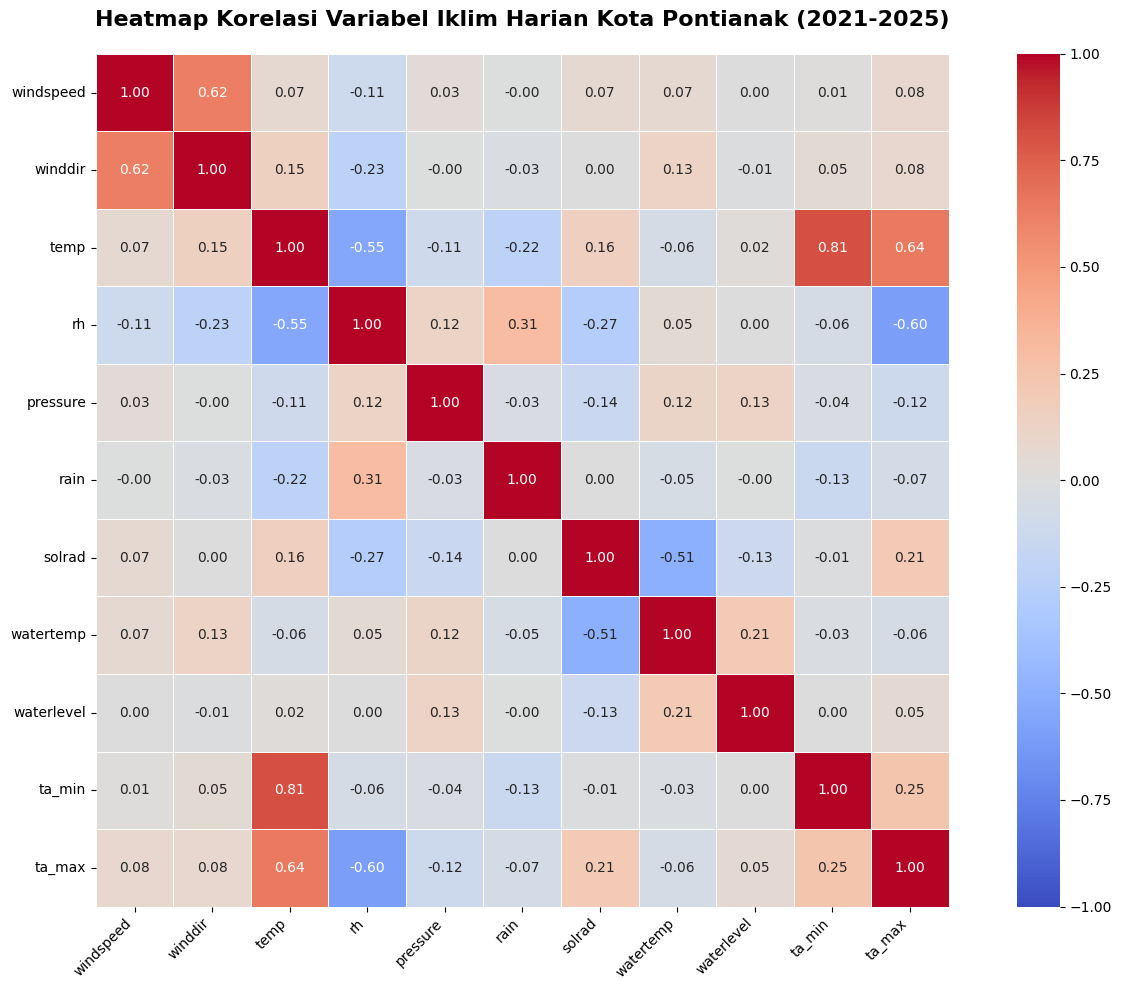


--- SELEKSI VARIABEL (MULTIKOLINEARITAS) ---
[INFO] Pasangan variabel dengan korelasi tinggi (|r| > 0.8):
 -> temp & ta_min : 0.807


In [ ]:
# ==========================================
# 1. IMPORT LIBRARY & HUBUNGKAN GOOGLE DRIVE
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Menghubungkan Google Colab dengan Google Drive
drive.mount('/content/drive')

# Setup path folder dan nama file
folder_path = '/content/drive/MyDrive/dataset'
file_name = 'final_full_dataset'

# Cek ekstensi file (csv atau xlsx) dan muat data
file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

print("\n--- PROSES LOADING DATA ---")
if os.path.exists(file_csv):
    print("Ditemukan file CSV. Membaca data...")
    df = pd.read_csv(file_csv)
elif os.path.exists(file_xlsx):
    print("Ditemukan file Excel (XLSX). Membaca data...")
    df = pd.read_excel(file_xlsx)
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path 'dataset/final_full_dataset' sudah benar di Google Drive.")

# Menampilkan informasi dasar dataset
print("\n[INFO] 5 Baris Teratas Dataset:")
display(df.head())

print(f"\n[INFO] Dimensi Dataset (Baris, Kolom): {df.shape}")

print("\n[INFO] Informasi Detail Dataset:")
df.info()


# ==========================================
# 2. PRAPROSES AWAL (MISSING VALUE & NUMERIK)
# ==========================================
print("\n--- PRAPROSES AWAL ---")
# Cek Missing Value
missing_values = df.isnull().sum()
print("[INFO] Jumlah Missing Value per Kolom:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada missing value (Data Bersih).")

# Mengabaikan kolom waktu dan mengambil hanya kolom numerik
if 'waktu' in df.columns:
    df_numeric = df.drop(columns=['waktu']).select_dtypes(include=[np.number])
else:
    df_numeric = df.select_dtypes(include=[np.number])

# [PENTING] Membuang kolom yang nilainya konstan (misal: pancilevel selalu 0)
# Kolom konstan akan menghasilkan nilai NaN pada korelasi Pearson
df_numeric = df_numeric.loc[:, df_numeric.std() > 0]

print(f"\n[INFO] Kolom numerik yang akan dianalisis ({len(df_numeric.columns)} kolom):")
print(df_numeric.columns.tolist())


# ==========================================
# 3. ANALISIS KORELASI PEARSON & HEATMAP
# ==========================================
print("\n--- ANALISIS KORELASI PEARSON ---")
# Menghitung matriks korelasi
corr_matrix = df_numeric.corr(method='pearson')

# Menampilkan tabel matriks korelasi
print("[INFO] Tabel Matriks Korelasi:")
display(corr_matrix.round(3))

# Visualisasi Heatmap Korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,          # Menampilkan angka korelasi
            cmap='coolwarm',     # Skema warna (biru negatif, merah positif)
            fmt=".2f",           # Format 2 angka di belakang koma
            vmin=-1, vmax=1,     # Batas nilai korelasi
            linewidths=0.5,      # Garis antar kotak
            square=True,
            annot_kws={"size": 10}) # Ukuran font angka
plt.title('Heatmap Korelasi Variabel Iklim Harian Kota Pontianak (2021-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ==========================================
# 4. SELEKSI VARIABEL (MULTIKOLINEARITAS)
# ==========================================
print("\n--- SELEKSI VARIABEL (MULTIKOLINEARITAS) ---")
threshold = 0.80  # Batas korelasi tinggi (|r| > 0.8)
high_corr_pairs =[]

# Mengambil segitiga atas dari matriks korelasi untuk menghindari duplikasi pasangan
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if abs(val) > threshold:
            high_corr_pairs.append((row, col, val))

print(f"[INFO] Pasangan variabel dengan korelasi tinggi (|r| > {threshold}):")
if not high_corr_pairs:
    print("Tidak ditemukan pasangan dengan korelasi > 0.80.")
else:
    for pair in high_corr_pairs:
        print(f" -> {pair[0]} & {pair[1]} : {pair[2]:.3f}")

1. PROSES LOADING DATA

Mounted at /content/drive
-> Berhasil memuat file CSV.
[INFO] Dimensi Dataset Awal: 1795 Baris, 7 Kolom

2. PEMILIHAN FITUR & PEMBERSIHAN DATA

-> Data bersih, tidak ditemukan missing value.

3. FEATURE ENGINEERING & NORMALISASI

-> Transformasi Logaritmik dan Normalisasi StandardScaler selesai.

4. REDUKSI DIMENSI (PCA)

-> PCA mereduksi dari 6 fitur menjadi 5 komponen utama.

5. EVALUASI JUMLAH KLASTER K-MEANS



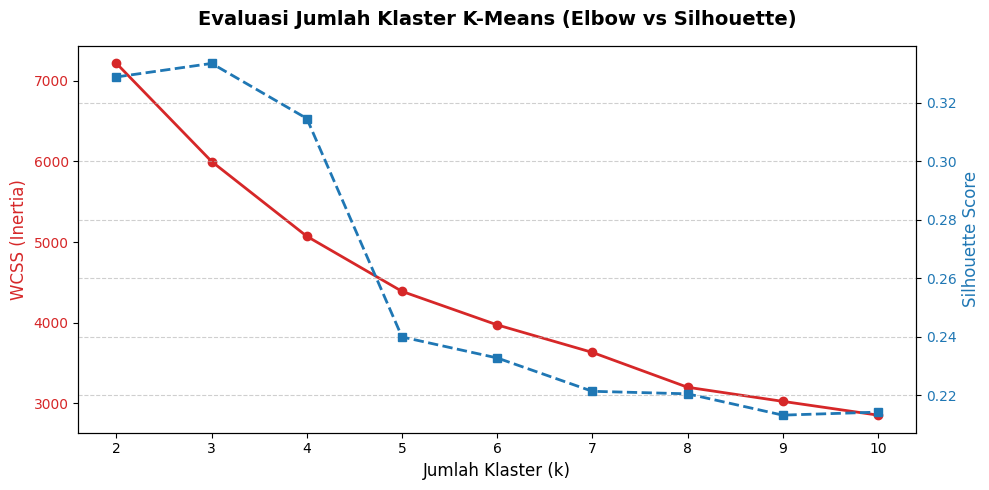

=> Jumlah klaster K-Means optimal adalah K = 3

6. EVALUASI KLASTER HIERARCHICAL



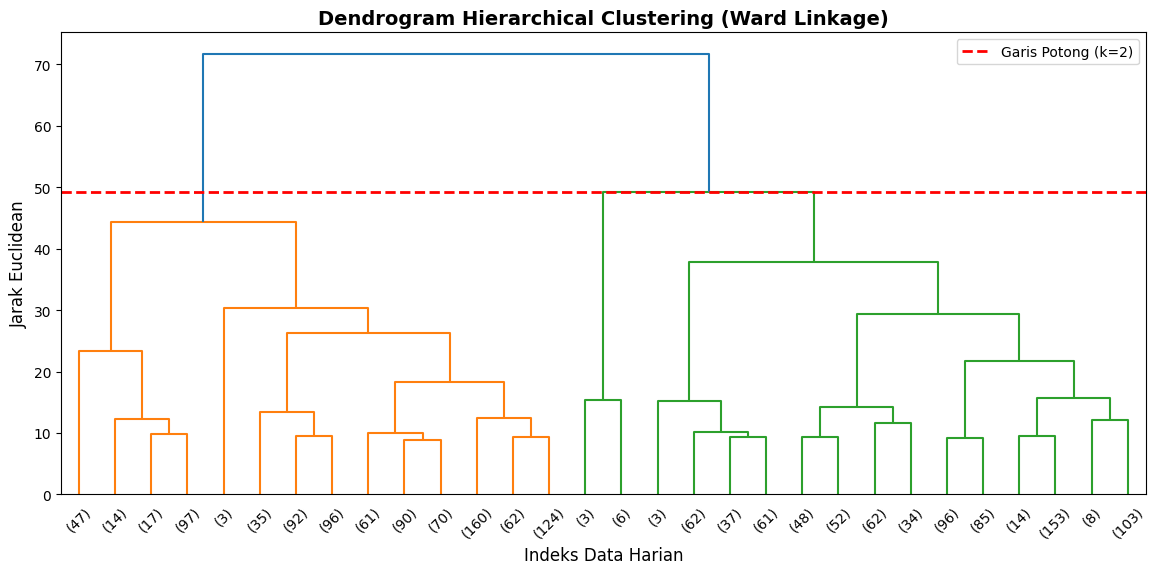

=> Jumlah klaster Hierarchical optimal adalah K = 2

7. IMPLEMENTASI CLUSTERING FINAL

-> Model berhasil dieksekusi.

8. VISUALISASI HASIL CLUSTERING (PCA 2D)



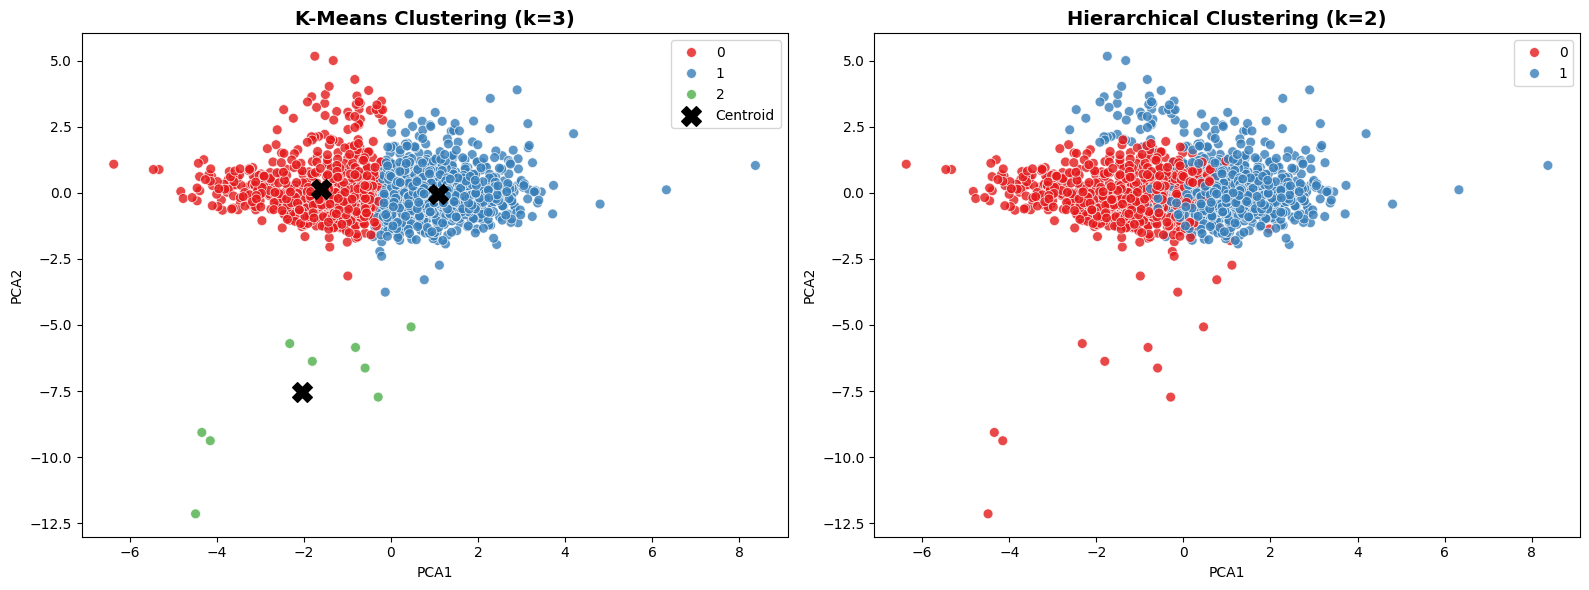


9. EVALUASI & KOMPARASI KINERJA MODEL



,Metode,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑)
0,K-Means (k=3),0.3335,0.9520,655.3200
1,Hierarchical (k=2),0.2576,1.4349,587.6685



10. PROFILING & INTERPRETASI KLASTER

--- Profil Karakteristik Klaster K-MEANS ---


,windspeed,temp,rh,pressure,rain,ta_max
KMeans_Cluster,,,,,,
0,1.18,28.66,77.24,1008.19,4.80,33.41
1,1.12,27.11,84.15,1008.36,11.99,31.45
2,1.02,28.19,78.35,973.26,22.38,33.42



--- Profil Karakteristik Klaster HIERARCHICAL ---


,windspeed,temp,rh,pressure,rain,ta_max
HC_Cluster,,,,,,
0,1.13,28.48,78.41,1007.69,6.07,33.21
1,1.16,27.08,83.95,1008.48,11.89,31.40



11. PENYIMPANAN DATA

[SUKSES] Dataset hasil clustering telah disimpan ke: /content/drive/MyDrive/dataset/hasil_clustering_final_terbaik.csv


In [ ]:
# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA
# ==========================================
print("==========================================")
print("1. PROSES LOADING DATA")
print("==========================================\n")

drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/dataset'
file_name = 'fix_noMissingValue'
file_csv = os.path.join(folder_path, f'{file_name}.csv')
file_xlsx = os.path.join(folder_path, f'{file_name}.xlsx')

if os.path.exists(file_csv):
    df = pd.read_csv(file_csv)
    print("-> Berhasil memuat file CSV.")
elif os.path.exists(file_xlsx):
    df = pd.read_excel(file_xlsx)
    print("-> Berhasil memuat file Excel.")
else:
    raise FileNotFoundError("File tidak ditemukan! Pastikan path benar di Google Drive.")

print(f"[INFO] Dimensi Dataset Awal: {df.shape[0]} Baris, {df.shape[1]} Kolom")

# ==========================================
# 2. PREPROCESSING & DATA CLEANING
# ==========================================
print("\n==========================================")
print("2. PEMILIHAN FITUR & PEMBERSIHAN DATA")
print("==========================================\n")

if 'waktu' in df.columns:
    df = df.dropna(subset=['waktu'])
    df['waktu'] = pd.to_datetime(df['waktu'])
    df = df.sort_values(by='waktu').reset_index(drop=True)

features =['windspeed', 'temp', 'rh', 'pressure', 'rain', 'ta_max']

# Memastikan seluruh fitur terbaca sebagai numerik (menangani spasi/karakter tersembunyi)
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputasi missing value menggunakan interpolasi linear
missing_total = df[features].isnull().sum().sum()
if missing_total > 0:
    print(f"-> Melakukan imputasi pada {missing_total} missing value...")
    df[features] = df[features].interpolate(method='linear', limit_direction='both')
    df[features] = df[features].bfill().ffill()
    print("-> Data berhasil dibersihkan.")
else:
    print("-> Data bersih, tidak ditemukan missing value.")

# ==========================================
# 3. FEATURE ENGINEERING & NORMALISASI
# ==========================================
print("\n==========================================")
print("3. FEATURE ENGINEERING & NORMALISASI")
print("==========================================\n")

# Menerapkan Rolling Average (3 hari) untuk menangkap tren deret waktu cuaca
df_rolling = df[features].rolling(window=3, min_periods=1).mean()

X = df_rolling.copy()

# Transformasi Logaritmik untuk mereduksi skewness pada curah hujan ekstrem
X['rain'] = np.log1p(X['rain'])

# Normalisasi menggunakan StandardScaler (Z-Score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("-> Transformasi Logaritmik dan Normalisasi StandardScaler selesai.")

# ==========================================
# 4. REDUKSI DIMENSI (PCA)
# ==========================================
print("\n==========================================")
print("4. REDUKSI DIMENSI (PCA)")
print("==========================================\n")

# Mempertahankan 95% variansi data
pca_model = PCA(n_components=0.95, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)
n_pca_components = X_pca.shape[1]

print(f"-> PCA mereduksi dari {len(features)} fitur menjadi {n_pca_components} komponen utama.")

# ==========================================
# 5. PENENTUAN JUMLAH KLASTER (K-MEANS)
# ==========================================
print("\n==========================================")
print("5. EVALUASI JUMLAH KLASTER K-MEANS")
print("==========================================\n")

wcss = []
silhouette_scores_kmeans =[]
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_pca, kmeans.labels_))

# Visualisasi Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color=color, fontsize=12)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores_kmeans, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Klaster K-Means (Elbow vs Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k_kmeans = K_range[np.argmax(silhouette_scores_kmeans)]
print(f"=> Jumlah klaster K-Means optimal adalah K = {best_k_kmeans}")

# ==========================================
# 6. PENENTUAN JUMLAH KLASTER (HIERARCHICAL)
# ==========================================
print("\n==========================================")
print("6. EVALUASI KLASTER HIERARCHICAL")
print("==========================================\n")

linkage_matrix = sch.linkage(X_pca, method='ward', metric='euclidean')
distances = linkage_matrix[:, 2]
jumps =[]
k_hc_range = list(range(2, 11))

for k in k_hc_range:
    jump = distances[-k+1] - distances[-k]
    jumps.append(jump)

best_k_hc = k_hc_range[np.argmax(jumps)]
cut_distance = distances[-best_k_hc]

plt.figure(figsize=(14, 6))
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Data Harian', fontsize=12)
plt.ylabel('Jarak Euclidean', fontsize=12)
dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (k={best_k_hc})')
plt.legend()
plt.show()

print(f"=> Jumlah klaster Hierarchical optimal adalah K = {best_k_hc}")

# ==========================================
# 7. IMPLEMENTASI MODEL FINAL
# ==========================================
print("\n==========================================")
print("7. IMPLEMENTASI CLUSTERING FINAL")
print("==========================================\n")

# K-Means
kmeans_final = KMeans(n_clusters=best_k_kmeans, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)
df['KMeans_Cluster'] = kmeans_labels

# Hierarchical
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X_pca)
df['HC_Cluster'] = hc_labels

print("-> Model berhasil dieksekusi.")

# ==========================================
# 8. VISUALISASI HASIL (PCA 2D)
# ==========================================
print("\n==========================================")
print("8. VISUALISASI HASIL CLUSTERING (PCA 2D)")
print("==========================================\n")

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='Set1', ax=ax1, s=50, alpha=0.8)
centroids_pca = kmeans_final.cluster_centers_
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroid')
ax1.set_title(f'K-Means Clustering (k={best_k_kmeans})', fontsize=14, fontweight='bold')
ax1.legend()

sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set1', ax=ax2, s=50, alpha=0.8)
ax2.set_title(f'Hierarchical Clustering (k={best_k_hc})', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 9. EVALUASI DAN KOMPARASI KINERJA MODEL
# ==========================================
print("\n==========================================")
print("9. EVALUASI & KOMPARASI KINERJA MODEL")
print("==========================================\n")

eval_data = {
    'Metode':[f'K-Means (k={best_k_kmeans})', f'Hierarchical (k={best_k_hc})'],
    'Silhouette Score (↑)':[
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, hc_labels)
    ],
    'Davies-Bouldin Index (↓)':[
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, hc_labels)
    ],
    'Calinski-Harabasz Index (↑)':[
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, hc_labels)
    ]
}
df_eval = pd.DataFrame(eval_data)
display(df_eval.round(4))

# ==========================================
# 10. PROFILING & INTERPRETASI KLASTER
# ==========================================
print("\n==========================================")
print("10. PROFILING & INTERPRETASI KLASTER")
print("==========================================\n")

print(f"--- Profil Karakteristik Klaster K-MEANS ---")
kmeans_profile = df.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile.round(2))

print(f"\n--- Profil Karakteristik Klaster HIERARCHICAL ---")
hc_profile = df.groupby('HC_Cluster')[features].mean()
display(hc_profile.round(2))

# ==========================================
# 11. PENYIMPANAN DATA
# ==========================================
print("\n==========================================")
print("11. PENYIMPANAN DATA")
print("==========================================\n")

df_final_export = df.drop(columns=['PCA1', 'PCA2'])
output_path = os.path.join(folder_path, 'hasil_clustering_final_terbaik.csv')
df_final_export.to_csv(output_path, index=False)

print(f"[SUKSES] Dataset hasil clustering telah disimpan ke: {output_path}")